# Task 8: Machine Learning Model House Price Prediction


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')

df = pd.read_csv('house_data.csv')
print(df.shape)
df.head()

(500, 7)


,Area_sqft,Bedrooms,Bathrooms,House_Age_years,Location_Score,Garage,Price
0,2024,3,2,22,1.9,1,327447
1,2178,3,3,12,7.6,1,440700
2,2257,3,2,4,4.5,1,363792
3,1204,4,4,3,8.1,0,288029
4,1161,4,5,27,5.4,1,231437


## 1. Exploratory Data Analysis

In [3]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,House_Age_years,Location_Score,Garage,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1809.898000,3.148000,3.154000,30.196000,5.552000,0.696000,303775.124000
std,592.844594,1.062239,1.296783,16.796483,2.508546,0.460443,77441.955425
min,400.000000,1.000000,1.000000,0.000000,1.000000,0.000000,100433.000000
25%,1414.750000,2.000000,2.000000,15.750000,3.475000,0.000000,251940.250000
50%,1822.500000,3.000000,3.000000,31.000000,5.700000,1.000000,303858.500000
75%,2199.750000,4.000000,4.000000,44.000000,7.625000,1.000000,355256.000000
max,3995.000000,5.000000,5.000000,59.000000,10.000000,1.000000,537211.000000


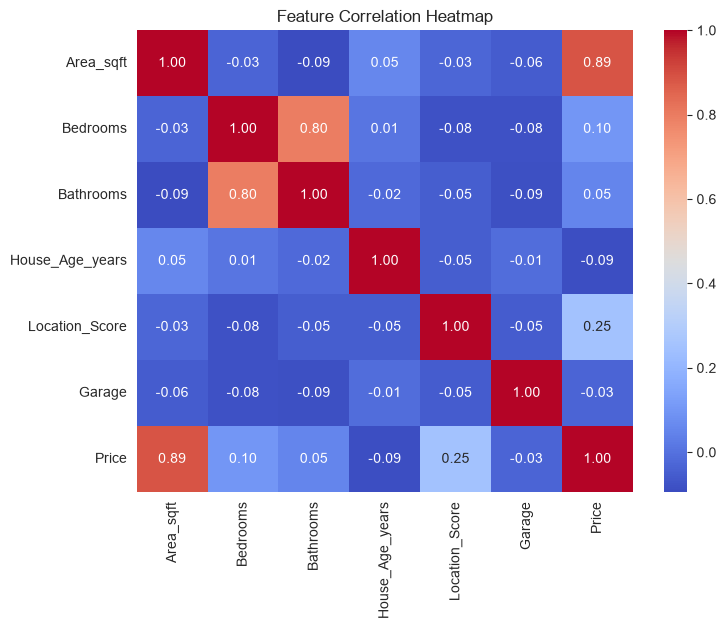

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

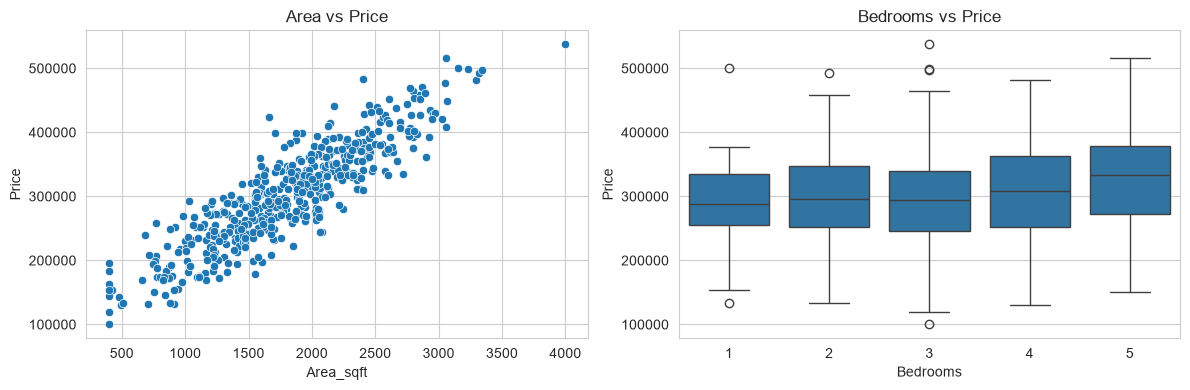

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=df, x='Area_sqft', y='Price', ax=axes[0]).set_title('Area vs Price')
sns.boxplot(data=df, x='Bedrooms', y='Price', ax=axes[1]).set_title('Bedrooms vs Price')
plt.tight_layout()
plt.savefig('eda_relationships.png', dpi=100)
plt.show()

## 2. Feature Selection & Train/Test Split

In [6]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (400, 6)  Test shape: (100, 6)


## 3. Model Training

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

In [12]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

## 4. Evaluation

In [13]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | RMSE: {rmse:,.0f} | R2: {r2:.3f}")
    return rmse, r2

lr_rmse, lr_r2 = evaluate("Linear Regression", y_test, lr_preds)
rf_rmse, rf_r2 = evaluate("Random Forest", y_test, rf_preds)

Linear Regression    | RMSE: 25,334 | R2: 0.903
Random Forest        | RMSE: 27,747 | R2: 0.884


In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
results

,Model,RMSE,R2 Score
0,Linear Regression,25334.293035,0.902962
1,Random Forest,27747.109195,0.883598


## 5. Feature Importance (Random Forest)

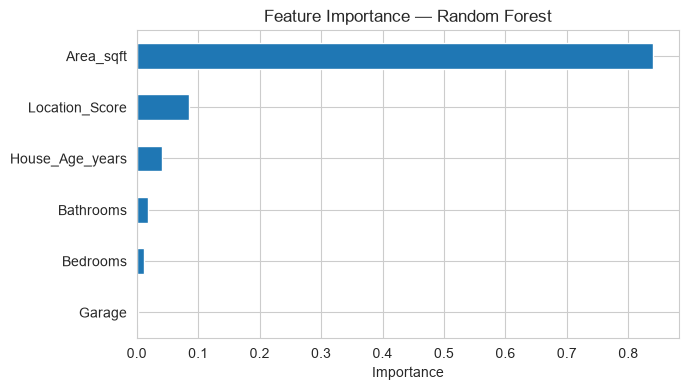

Area_sqft          0.840793
Location_Score     0.084268
House_Age_years    0.041911
Bathrooms          0.018835
Bedrooms           0.011874
Garage             0.002319
dtype: float64

In [15]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7,4))
importance.plot(kind='barh')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png', dpi=100)
plt.show()
importance

## 6. Predicted vs Actual

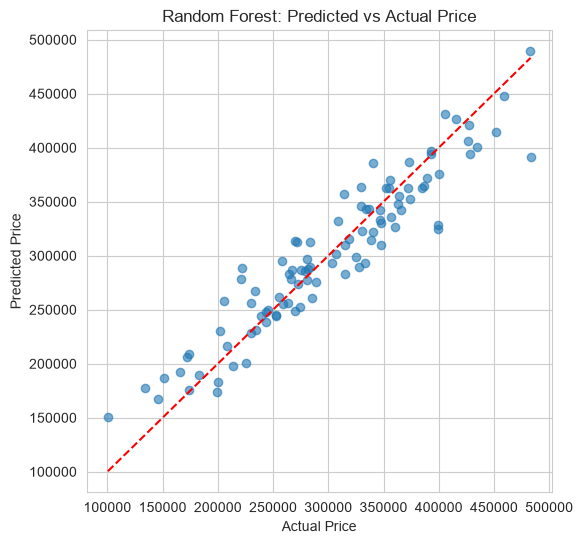

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Predicted vs Actual Price')
plt.savefig('predicted_vs_actual.png', dpi=100)
plt.show()

## 7. Example Prediction (User Input → Prediction Output)

In [17]:
def predict_price(area, bedrooms, bathrooms, house_age, location_score, garage):
    sample = pd.DataFrame([{
        'Area_sqft': area,
        'Bedrooms': bedrooms,
        'Bathrooms': bathrooms,
        'House_Age_years': house_age,
        'Location_Score': location_score,
        'Garage': garage
    }])
    return rf.predict(sample)[0]

example = predict_price(area=2200, bedrooms=3, bathrooms=2, house_age=5, location_score=8.5, garage=1)
print(f"Predicted price for example house: ${example:,.0f}")

Predicted price for example house: $385,986
